# Explore CelebA

In [7]:
from pathlib import Path

import pandas as pd
from PIL import Image

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate the project root from the current notebook session.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CELEBA_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'raw' / 'celeba'
IMAGE_CONTAINER_ROOT = CELEBA_ROOT / 'img_align_celeba'
IMAGE_ROOT = IMAGE_CONTAINER_ROOT / 'img_align_celeba' if (IMAGE_CONTAINER_ROOT / 'img_align_celeba').exists() else IMAGE_CONTAINER_ROOT

print('Project root:', PROJECT_ROOT)
print('CelebA root exists:', CELEBA_ROOT.exists())
print('Image root exists:', IMAGE_ROOT.exists())


Project root: .
CelebA root exists: True
Image root exists: True


In [8]:
files = sorted(path.name for path in CELEBA_ROOT.iterdir())
pd.DataFrame({'name': files})


,name
0,img_align_celeba
1,list_attr_celeba.csv
2,list_bbox_celeba.csv
3,list_eval_partition.csv
4,list_landmarks_align_celeba.csv


In [9]:
image_paths = sorted(IMAGE_ROOT.glob('*.jpg'))
summary = {
    'image_count': len(image_paths),
    'first_image': image_paths[0].name if image_paths else None,
    'last_image': image_paths[-1].name if image_paths else None,
}
pd.Series(summary)


image_count        202599
first_image    000001.jpg
last_image     202599.jpg
dtype: object

In [10]:
attr_df = pd.read_csv(CELEBA_ROOT / 'list_attr_celeba.csv')
bbox_df = pd.read_csv(CELEBA_ROOT / 'list_bbox_celeba.csv')
partition_df = pd.read_csv(CELEBA_ROOT / 'list_eval_partition.csv')
landmarks_df = pd.read_csv(CELEBA_ROOT / 'list_landmarks_align_celeba.csv')

shape_summary = pd.DataFrame(
    [
        {'table': 'attributes', 'rows': len(attr_df), 'cols': len(attr_df.columns)},
        {'table': 'bounding_boxes', 'rows': len(bbox_df), 'cols': len(bbox_df.columns)},
        {'table': 'partitions', 'rows': len(partition_df), 'cols': len(partition_df.columns)},
        {'table': 'landmarks', 'rows': len(landmarks_df), 'cols': len(landmarks_df.columns)},
    ]
)
shape_summary


,table,rows,cols
0,attributes,202599,41
1,bounding_boxes,202599,5
2,partitions,202599,2
3,landmarks,202599,11


In [11]:
hair_related_columns = [
    column
    for column in attr_df.columns
    if 'Hair' in column or 'Bangs' in column or 'Bald' in column or 'Receding' in column
]

attr_df[hair_related_columns].replace({-1: 0, 1: 1}).mean().sort_values(ascending=False)


Wavy_Hair            0.319567
Black_Hair           0.239251
Straight_Hair        0.208402
Brown_Hair           0.205194
Bangs                0.151575
Blond_Hair           0.147992
Receding_Hairline    0.079778
Gray_Hair            0.041950
Bald                 0.022443
dtype: float64

Sample image: 000001.jpg
Size: (178, 218)


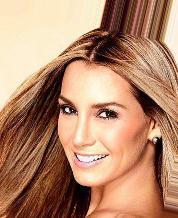

In [12]:
if image_paths:
    sample_image_path = image_paths[0]
    with Image.open(sample_image_path) as sample_image:
        print('Sample image:', sample_image_path.name)
        print('Size:', sample_image.size)
        display(sample_image)
else:
    print('No JPG images were found under', IMAGE_ROOT)


In [13]:
merged_preview = (
    attr_df[['image_id'] + hair_related_columns]
    .merge(partition_df, on='image_id', how='left')
    .merge(bbox_df, on='image_id', how='left')
    .merge(landmarks_df, on='image_id', how='left')
)
merged_preview.head()


,image_id,Bald,Bangs,Black_Hair,Blond_Hair,Brown_Hair,Gray_Hair,Receding_Hairline,Straight_Hair,Wavy_Hair,...,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,-1,-1,-1,-1,1,-1,-1,1,-1,...,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,-1,-1,-1,-1,1,-1,-1,-1,-1,...,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,-1,-1,-1,-1,-1,-1,-1,1,-1,...,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,66,114,112,112,86,119,71,147,104,150


## Takeaways

- `CelebA` gives us aligned face photos plus structured attribute, partition, box, and landmark tables.
- Hair-related attribute columns already exist and can support later dataset enrichment.
- We should keep the preprocessing notebooks responsible for converting these raw CSVs into the Version 1 training and asset manifests.
